In [12]:
  # 한글 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [13]:
import pandas as pd

# 1. 데이터 로드
try:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='utf-8-sig')

# 2. 명세서 기반 필요한 변수 리스트 (기온 7개 + 강수/습도/일조 5개 추가)
target_cols = [
    # 기온 관련 변수
    '평균기온(°C)',
    '평균최고기온(°C)',
    '평균최저기온(°C)',
    '최고기온(°C)',
    '최저기온(°C)',
    '최고기온 나타난날(yyyymmdd)',
    '최저기온 나타난날(yyyymmdd)',

    # 강수, 습도, 일조 관련 변수 (새로 추가된 항목)
    '합계 강수량(mm)',
    '일 최다 강수량(mm)',
    '평균 상대습도(%)',
    '합계 일조시간(hr)',
    '일조율(%)'
]

# 3. 변수별 결측치 개수 및 비율 계산
null_counts = df[target_cols].isnull().sum()
null_percent = (df[target_cols].isnull().sum() / len(df)) * 100

# 4. 결과를 보기 좋게 데이터프레임으로 통합하여 출력
null_summary = pd.DataFrame({
    '결측치 개수': null_counts,
    '결측치 비율(%)': null_percent.round(2)
})

print("=== 지정 변수(총 12개) 결측치 점검 결과 ===")
print(null_summary)

=== 지정 변수(총 12개) 결측치 점검 결과 ===
                     결측치 개수  결측치 비율(%)
평균기온(°C)                  6       2.33
평균최고기온(°C)                4       1.55
평균최저기온(°C)                4       1.55
최고기온(°C)                  0       0.00
최저기온(°C)                  0       0.00
최고기온 나타난날(yyyymmdd)       0       0.00
최저기온 나타난날(yyyymmdd)       0       0.00
합계 강수량(mm)                0       0.00
일 최다 강수량(mm)              0       0.00
평균 상대습도(%)                4       1.55
합계 일조시간(hr)               0       0.00
일조율(%)                    0       0.00


In [14]:
import pandas as pd

# 1. 데이터 불러오기 (기상청 데이터 특성상 cp949 인코딩 사용)
try:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='utf-8')

# 2. 분석에 필요한 12가지 핵심 변수 설정 (기온 7개 + 강수/습도/일조 5개 추가)
target_cols = [
    # 기온 관련 변수
    '평균기온(°C)',
    '평균최고기온(°C)',
    '평균최저기온(°C)',
    '최고기온(°C)',
    '최저기온(°C)',
    '최고기온 나타난날(yyyymmdd)',
    '최저기온 나타난날(yyyymmdd)',

    # 강수, 습도, 일조 관련 변수 (새로 추가된 항목)
    '합계 강수량(mm)',
    '일 최다 강수량(mm)',
    '평균 상대습도(%)',
    '합계 일조시간(hr)',
    '일조율(%)'
]

print("=== 4.1 결측치 확인 결과 ===")
# 변수별 결측치 개수
null_counts = df[target_cols].isnull().sum()
# 변수별 결측 비율 (%)
null_percent = (null_counts / len(df)) * 100

# 결과 출력
missing_info = pd.concat([null_counts, null_percent], axis=1)
missing_info.columns = ['결측치 개수', '결측 비율(%)']
print(missing_info)
print("\n")

print("=== 4.2 중복 데이터 확인 결과 ===")
# 전체 행이 완전히 일치하는 중복 데이터 확인
total_duplicates = df.duplicated().sum()

# 지점명과 일시(연도)가 모두 중복되는 데이터 확인 (데이터 ID 성격)
id_duplicates = df.duplicated(subset=['지점명', '일시']).sum()

print(f"전체 행 중복 개수: {total_duplicates}")
print(f"지점/일시(ID) 중복 개수: {id_duplicates}")

# 3. 결측치 제거 후 데이터 저장
# 확장된 12개 변수 중 하나라도 결측치가 있는 행을 제거한 데이터프레임을 생성합니다.
df_clean = df.dropna(subset=target_cols)

print("\n=== 데이터 정제 결과 ===")
print(f"원래 데이터 행 수: {len(df)}")
print(f"정제 후 데이터 행 수: {len(df_clean)}")
print(f"제거된 행 수: {len(df) - len(df_clean)}")

# 정제된 데이터를 새로운 파일로 저장
df_clean.to_csv('기상_데이터_정제본.csv', index=False, encoding='cp949')

=== 4.1 결측치 확인 결과 ===
                     결측치 개수  결측 비율(%)
평균기온(°C)                  6  2.325581
평균최고기온(°C)                4  1.550388
평균최저기온(°C)                4  1.550388
최고기온(°C)                  0  0.000000
최저기온(°C)                  0  0.000000
최고기온 나타난날(yyyymmdd)       0  0.000000
최저기온 나타난날(yyyymmdd)       0  0.000000
합계 강수량(mm)                0  0.000000
일 최다 강수량(mm)              0  0.000000
평균 상대습도(%)                4  1.550388
합계 일조시간(hr)               0  0.000000
일조율(%)                    0  0.000000


=== 4.2 중복 데이터 확인 결과 ===
전체 행 중복 개수: 0
지점/일시(ID) 중복 개수: 0

=== 데이터 정제 결과 ===
원래 데이터 행 수: 258
정제 후 데이터 행 수: 252
제거된 행 수: 6


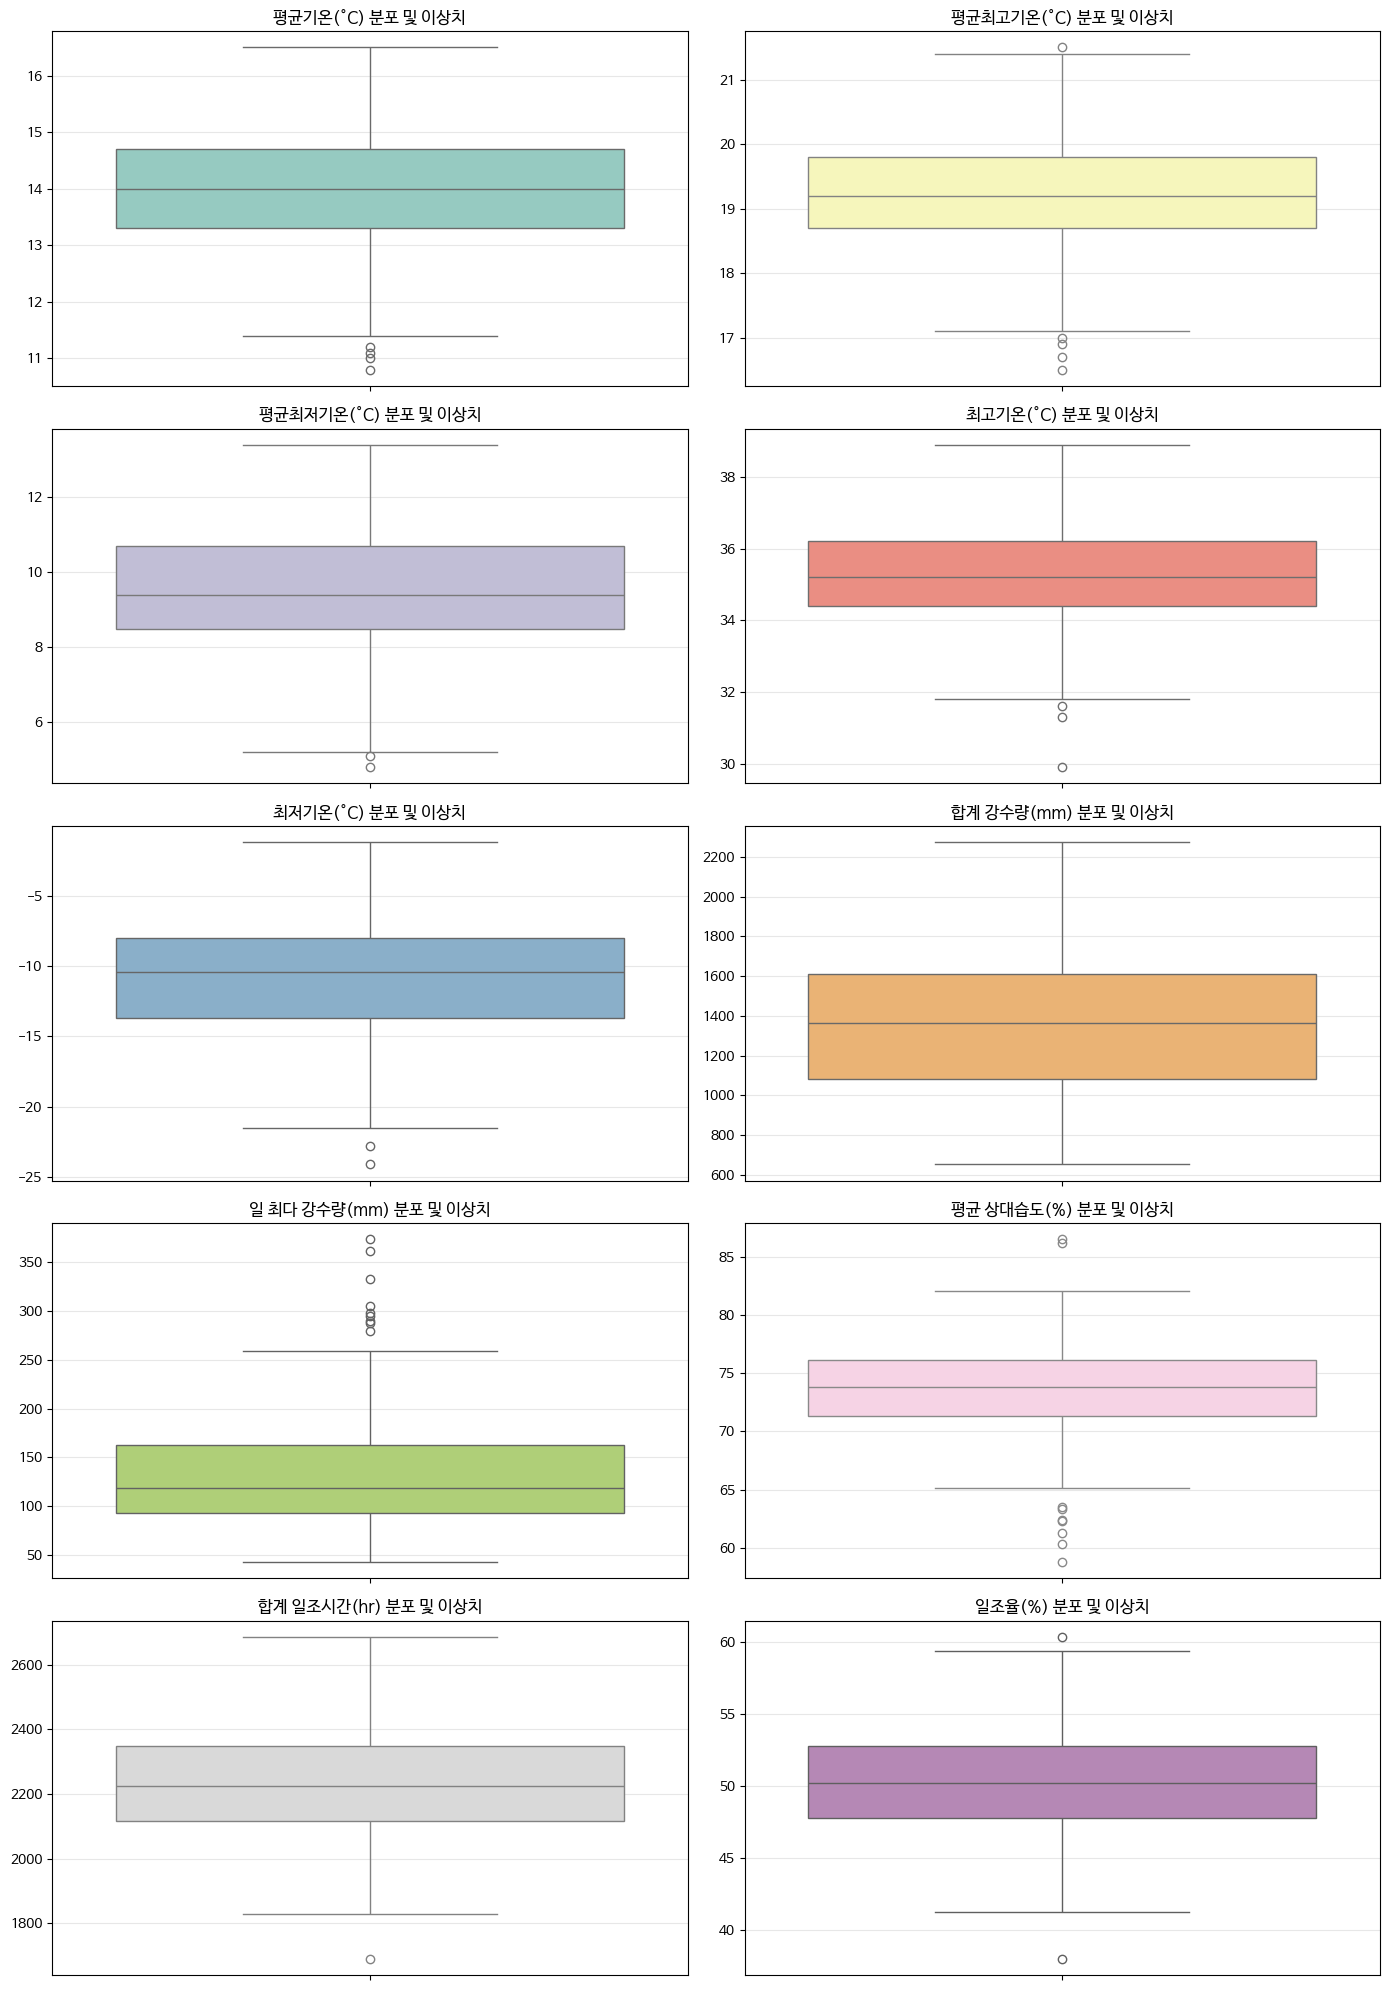

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [코랩 전용 한글 폰트 설정 추가]
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 및 정제
try:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='utf-8')

target_cols = [
    '평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)', '최고기온(°C)', '최저기온(°C)',
    '합계 강수량(mm)', '일 최다 강수량(mm)', '평균 상대습도(%)', '합계 일조시간(hr)', '일조율(%)'
]
df_clean = df.dropna(subset=target_cols)

# 2. 5행 2열(총 10칸)의 개별 그래프 화면 생성
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten() # 2차원 배열을 1차원으로 펼쳐서 반복문 쓰기 편하게 변환

# 각 변수의 색상을 다르게 지정하기 위한 팔레트
colors = sns.color_palette('Set3', 10)

# 3. 반복문을 돌며 각 칸에 변수 1개씩 독립적으로 그리기
for i, col in enumerate(target_cols):
    sns.boxplot(data=df_clean, y=col, ax=axes[i], color=colors[i])
    axes[i].set_title(f'{col} 분포 및 이상치')
    axes[i].set_ylabel('') # y축 라벨은 타이틀과 겹치므로 생략
    axes[i].grid(True, axis='y', alpha=0.3) # 가로선 격자 추가로 가독성 업

# 빈 공간 조절 및 출력
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

# 1. 파일 불러오기 (실제 파일명인 '기상 데이터 15~25까지.csv'로 지정)
try:
    df = pd.read_csv('기상_데이터_정제본.csv', encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv('기상_데이터_정제본.csv', encoding='utf-8')

# 2. 분석에 필요한 10가지 핵심 변수 설정 (기온 5개 + 강수/습도/일조 5개)
target_cols = [
    '평균기온(°C)',
    '평균최고기온(°C)',
    '평균최저기온(°C)',
    '최고기온(°C)',
    '최저기온(°C)',
    '합계 강수량(mm)',
    '일 최다 강수량(mm)',
    '평균 상대습도(%)',
    '합계 일조시간(hr)',
    '일조율(%)'
]

# 3. 결측치를 제거한 새로운 데이터프레임 생성 (df_clean)
df_clean = df.dropna(subset=target_cols)

# 4. 기술 통계량 산출 (평균, 표준편차, 최솟값, 25%, 50%, 75%, 최댓값)
stats_summary = df_clean[target_cols].describe()

# 5. 중앙값(Median)과 왜도(Skewness) 추가 계산
stats_summary.loc['median'] = df_clean[target_cols].median()
stats_summary.loc['skewness'] = df_clean[target_cols].skew()

# 결과 출력 (소수점 둘째자리까지)
print("=== 5.1 수치형 변수(총 10개) 기술 통계 요약 ===")
print(stats_summary.round(2))

print("\n--- [보고서 작성 팁] ---")
print(f"최종 분석에 사용된 데이터 수: {len(df_clean)}개")

=== 5.1 수치형 변수(총 10개) 기술 통계 요약 ===
          평균기온(°C)  평균최고기온(°C)  평균최저기온(°C)  최고기온(°C)  최저기온(°C)  합계 강수량(mm)  \
count       252.00      252.00      252.00    252.00    252.00      252.00   
mean         13.95       19.21        9.43     35.23    -10.94     1362.14   
std           1.05        0.89        1.65      1.38      4.04      350.27   
min          10.80       16.50        4.80     29.90    -24.10      652.80   
25%          13.30       18.70        8.48     34.40    -13.72     1084.12   
50%          14.00       19.20        9.40     35.20    -10.45     1361.75   
75%          14.70       19.80       10.70     36.20     -8.00     1608.80   
max          16.50       21.50       13.40     38.90     -1.20     2274.60   
median       14.00       19.20        9.40     35.20    -10.45     1361.75   
skewness     -0.36       -0.23       -0.11     -0.28     -0.39        0.17   

          일 최다 강수량(mm)  평균 상대습도(%)  합계 일조시간(hr)  일조율(%)  
count           252.00      252.00       252.00 

In [17]:
# '지점명'으로 그룹을 묶어서 각 지역별 표준편차(std)만 계산
region_std = df_clean.groupby('지점명')[target_cols].std()

print("=== 지역별 기온 표준편차(std) 확인 ===")
print(region_std.round(2))

# 가장 변동이 심한 지역과 안정적인 지역 확인용
print("\n--- 분석 결과 ---")
print(f"최저기온 변동이 가장 큰 지역: {region_std['최저기온(°C)'].idxmax()}")
print(f"최저기온이 가장 안정적인 지역: {region_std['최저기온(°C)'].idxmin()}")

=== 지역별 기온 표준편차(std) 확인 ===
         평균기온(°C)  평균최고기온(°C)  평균최저기온(°C)  최고기온(°C)  최저기온(°C)  합계 강수량(mm)  \
지점명                                                                         
강진군          0.58        0.64        0.58      1.22      3.42      261.54   
고창           0.38        0.34        0.50      1.03      2.80      289.94   
고창군          0.63        0.55        0.72      1.13      3.09      296.76   
고흥           0.66        0.75        0.74      1.27      2.36      259.29   
광양시          0.38        0.46        0.42      1.17      2.30      421.32   
군산           0.49        0.44        0.56      0.80      2.95      408.09   
남원           0.60        0.48        0.75      1.07      3.12      399.43   
목포           0.50        0.51        0.52      1.06      2.99      273.27   
보성군          0.48        0.48        0.63      0.74      2.08      350.50   
부안           0.58        0.50        0.67      0.88      3.38      316.05   
순창군          0.67        0.57        0.81      1

/tmp/ipykernel_8969/1256892130.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='지점명', order=category_counts.index, palette='pastel')


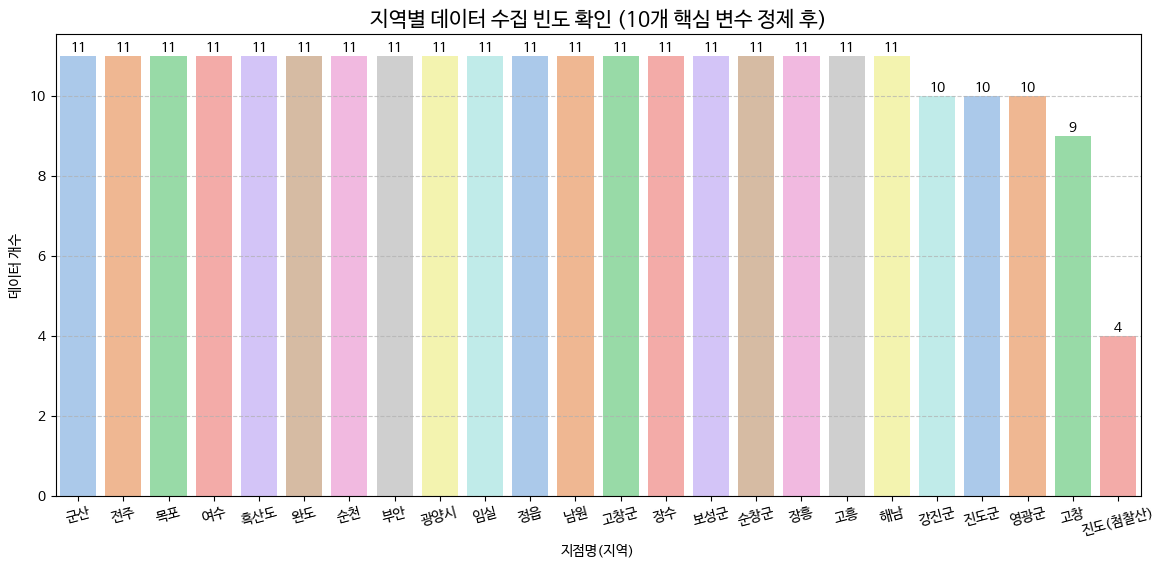


       [ 5.2 범주형 변수(지점명) 분석 상세 결과 ]
         빈도(개수)  비율(%)
지점명                   
군산           11   4.37
전주           11   4.37
목포           11   4.37
여수           11   4.37
흑산도          11   4.37
완도           11   4.37
순천           11   4.37
부안           11   4.37
광양시          11   4.37
임실           11   4.37
정읍           11   4.37
남원           11   4.37
고창군          11   4.37
장수           11   4.37
보성군          11   4.37
순창군          11   4.37
장흥           11   4.37
고흥           11   4.37
해남           11   4.37
강진군          10   3.97
진도군          10   3.97
영광군          10   3.97
고창            9   3.57
진도(첨찰산)       4   1.59
--------------------------------------------------
총 데이터 개수(정제 후): 252개
고유 지역 수: 24개


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [코랩 전용 한글 폰트 설정 추가]
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 파일 불러오기 및 데이터 정제 (기온 5개 + 강수/습도/일조 5개 총 10개 핵심 변수 기준)
try:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='utf-8')

target_cols = [
    '평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)', '최고기온(°C)', '최저기온(°C)',
    '합계 강수량(mm)', '일 최다 강수량(mm)', '평균 상대습도(%)', '합계 일조시간(hr)', '일조율(%)'
]
df_clean = df.dropna(subset=target_cols)

# 2. 범주형 변수(지점명) 빈도 및 비율 계산
category_counts = df_clean['지점명'].value_counts()
category_percent = df_clean['지점명'].value_counts(normalize=True) * 100

# 표 형태로 출력하기 위해 데이터프레임 생성
category_analysis = pd.concat([category_counts, category_percent], axis=1)
category_analysis.columns = ['빈도(개수)', '비율(%)']

# 3. 시각화 (막대그래프)
plt.figure(figsize=(14, 6)) # 지역명이 많아질 경우를 대비해 가로 크기를 살짝 늘렸습니다
ax = sns.countplot(data=df_clean, x='지점명', order=category_counts.index, palette='pastel')

# 막대 위에 숫자 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.title('지역별 데이터 수집 빈도 확인 (10개 핵심 변수 정제 후)', fontsize=15)
plt.xlabel('지점명(지역)')
plt.ylabel('데이터 개수')
plt.xticks(rotation=15) # 지역명이 많아 글자가 겹칠 때를 대비해 약간의 각도를 주었습니다
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. 아래에 텍스트 결과 출력
print("\n" + "="*50)
print("       [ 5.2 범주형 변수(지점명) 분석 상세 결과 ]")
print("="*50)
print(category_analysis.round(2))
print("-" * 50)
print(f"총 데이터 개수(정제 후): {len(df_clean)}개")
print(f"고유 지역 수: {len(category_counts)}개")
print("="*50)

In [19]:
import pandas as pd

# 1. 파일 불러오기
df = pd.read_csv('기상_데이터_정제본.csv', encoding='cp949')

print("=== 4.4 데이터 일관성 점검 결과 ===\n")

# [체크 1] 지점명 불일치 및 오탈자 확인 (비슷한 이름이 있는지 확인)
print("1. 지점명 일관성:")
unique_locations = sorted(df['지점명'].unique())
print(f"고유 지점 수: {len(unique_locations)}개")
print(f"지점 리스트: {unique_locations[:5]} ... 등")

# [체크 2] 날짜 형식 오류 점검 (날짜로 변환되지 않는 값이 있는지)
print("\n2. 날짜 형식 일관성:")
invalid_dates = pd.to_datetime(df['일시'], errors='coerce').isna().sum()
if invalid_dates == 0:
    print("결과: 모든 날짜 데이터가 올바른 형식입니다.")
else:
    print(f"경고: {invalid_dates}개의 날짜 데이터에 오류가 있습니다.")

# [체크 3] 온도 단위 및 논리적 오류 점검 (최고기온이 최저기온보다 낮은 경우 등)
print("\n3. 온도 데이터 논리성 검사:")
logic_error = df[df['최고기온(°C)'] < df['최저기온(°C)']]
if len(logic_error) == 0:
    print("결과: 최고기온이 최저기온보다 낮은 논리적 오류가 없습니다.")
else:
    print(f"경고: {len(logic_error)}건의 논리적 오류 데이터 발견!")

# [체크 4] 범주형 변수 공백 확인
space_check = df['지점명'].str.contains(' ').sum()
print(f"\n4. 텍스트 공백 검사: 지점명 내 불필요한 공백 {space_check}건 발견")

=== 4.4 데이터 일관성 점검 결과 ===

1. 지점명 일관성:
고유 지점 수: 24개
지점 리스트: ['강진군', '고창', '고창군', '고흥', '광양시'] ... 등

2. 날짜 형식 일관성:
결과: 모든 날짜 데이터가 올바른 형식입니다.

3. 온도 데이터 논리성 검사:
결과: 최고기온이 최저기온보다 낮은 논리적 오류가 없습니다.

4. 텍스트 공백 검사: 지점명 내 불필요한 공백 0건 발견


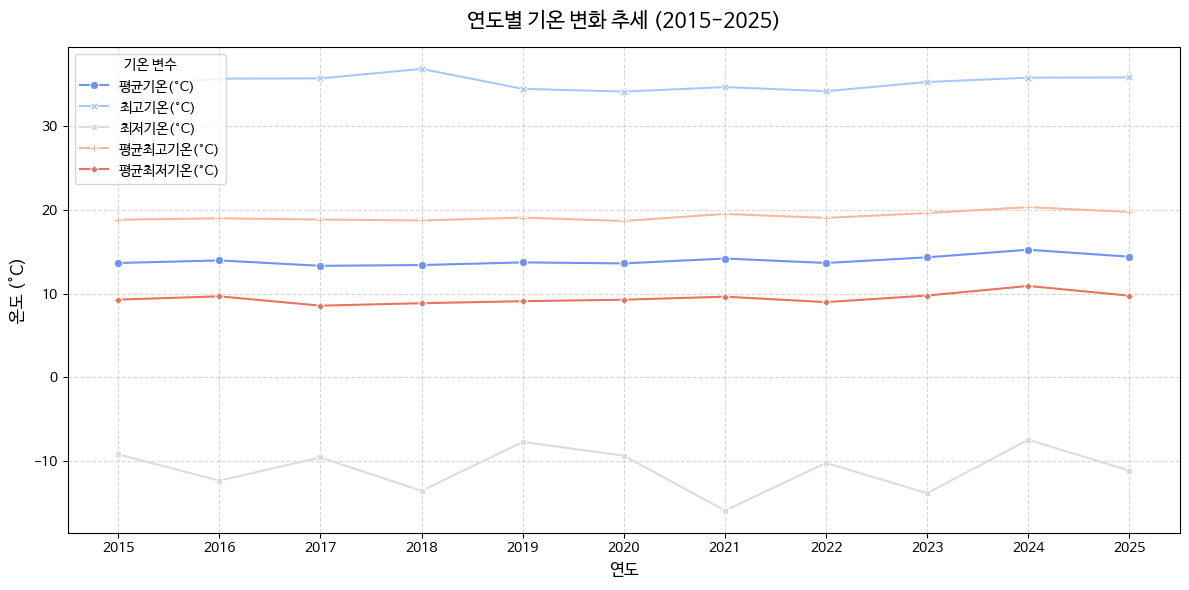

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [코랩 전용 한글 폰트 설정 추가]
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 및 연도 추출
try:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='utf-8')

# '일시' 데이터에서 안전하게 4자리 연도 추출
df['연도'] = df['일시'].astype(str).str[:4].astype(int)

# 기온 변수 정제 및 연도별 평균치 계산
temp_cols = ['평균기온(°C)', '최고기온(°C)', '최저기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)']
df_temp = df.dropna(subset=temp_cols)
yearly_temp = df_temp.groupby('연도')[temp_cols].mean()

# 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_temp, markers=True, dashes=False, palette='coolwarm')

plt.title('연도별 기온 변화 추세 (2015-2025)', fontsize=15, pad=15)
plt.xlabel('연도', fontsize=12)
plt.ylabel('온도 (°C)', fontsize=12)
plt.xticks(yearly_temp.index)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='기온 변수', loc='upper left')

plt.tight_layout()
plt.show()

/tmp/ipykernel_8969/1736711066.py:37: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=yearly_etc[small_cols], markers='o', dashes=[(2,2), (2,2), (2,2)], ax=ax2, palette='Set2')


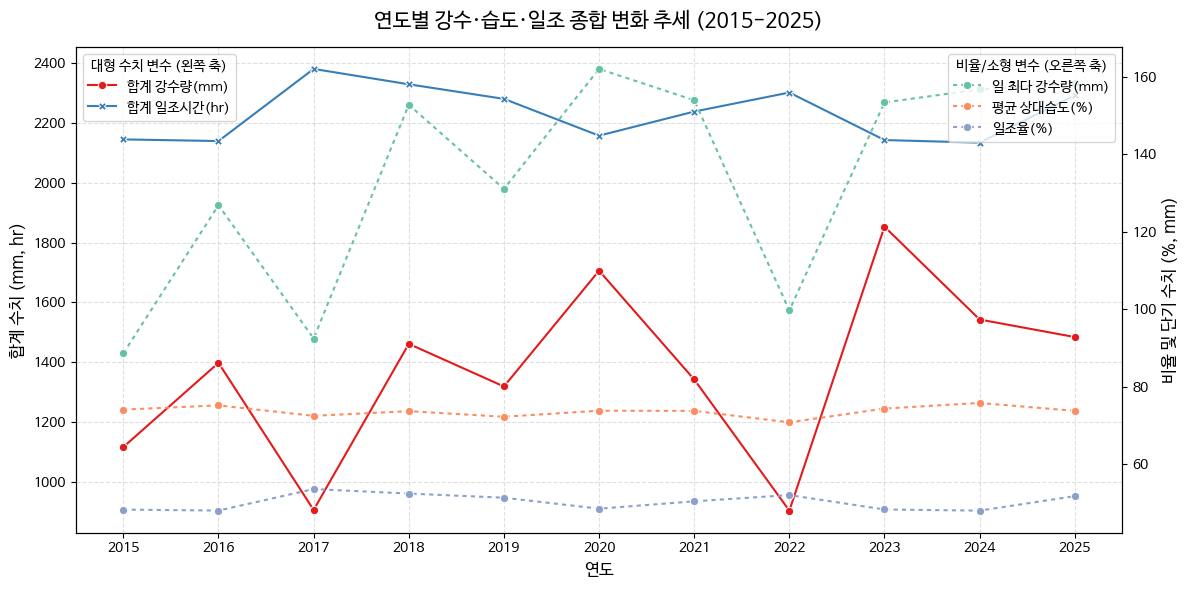

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [코랩 전용 한글 폰트 설정 추가]
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 및 연도 추출
try:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='utf-8')

# '일시' 데이터에서 안전하게 4자리 연도 추출
df['연도'] = df['일시'].astype(str).str[:4].astype(int)

# 기타 기상 변수 정제 및 연도별 평균치 계산
etc_cols = ['합계 강수량(mm)', '합계 일조시간(hr)', '일 최다 강수량(mm)', '평균 상대습도(%)', '일조율(%)']
df_etc = df.dropna(subset=etc_cols)
yearly_etc = df_etc.groupby('연도')[etc_cols].mean()

# 시각화 시작
fig, ax1 = plt.subplots(figsize=(12, 6))

# 왼쪽 Y축 (ax1): 값이 큰 변수들 (합계 강수량, 합계 일조시간) -> 실선 표시
large_cols = ['합계 강수량(mm)', '합계 일조시간(hr)']
sns.lineplot(data=yearly_etc[large_cols], markers=True, dashes=False, ax=ax1, palette='Set1')
ax1.set_ylabel('합계 수치 (mm, hr)', fontsize=12)
ax1.set_xlabel('연도', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.4)

# 오른쪽 Y축 (ax2): 값이 작은 비율/단기 변수들 (일최다강수량, 상대습도, 일조율) -> 점선 표시
ax2 = ax1.twinx()
small_cols = ['일 최다 강수량(mm)', '평균 상대습도(%)', '일조율(%)']
# 구분을 더 쉽게 하기 위해 오른쪽 축 변수들은 대시 스타일(Dashes)을 적용합니다
sns.lineplot(data=yearly_etc[small_cols], markers='o', dashes=[(2,2), (2,2), (2,2)], ax=ax2, palette='Set2')
ax2.set_ylabel('비율 및 단기 수치 (%, mm)', fontsize=12)

# 타이틀 및 범례 합치기 정리
plt.title('연도별 강수·습도·일조 종합 변화 추세 (2015-2025)', fontsize=15, pad=15)
ax1.set_xticks(yearly_etc.index)

# 두 축의 범례가 겹치지 않게 각각 좌상단, 우상단 분할 배치
ax1.legend(title='대형 수치 변수 (왼쪽 축)', loc='upper left')
ax2.legend(title='비율/소형 변수 (오른쪽 축)', loc='upper right')

plt.tight_layout()
plt.show()

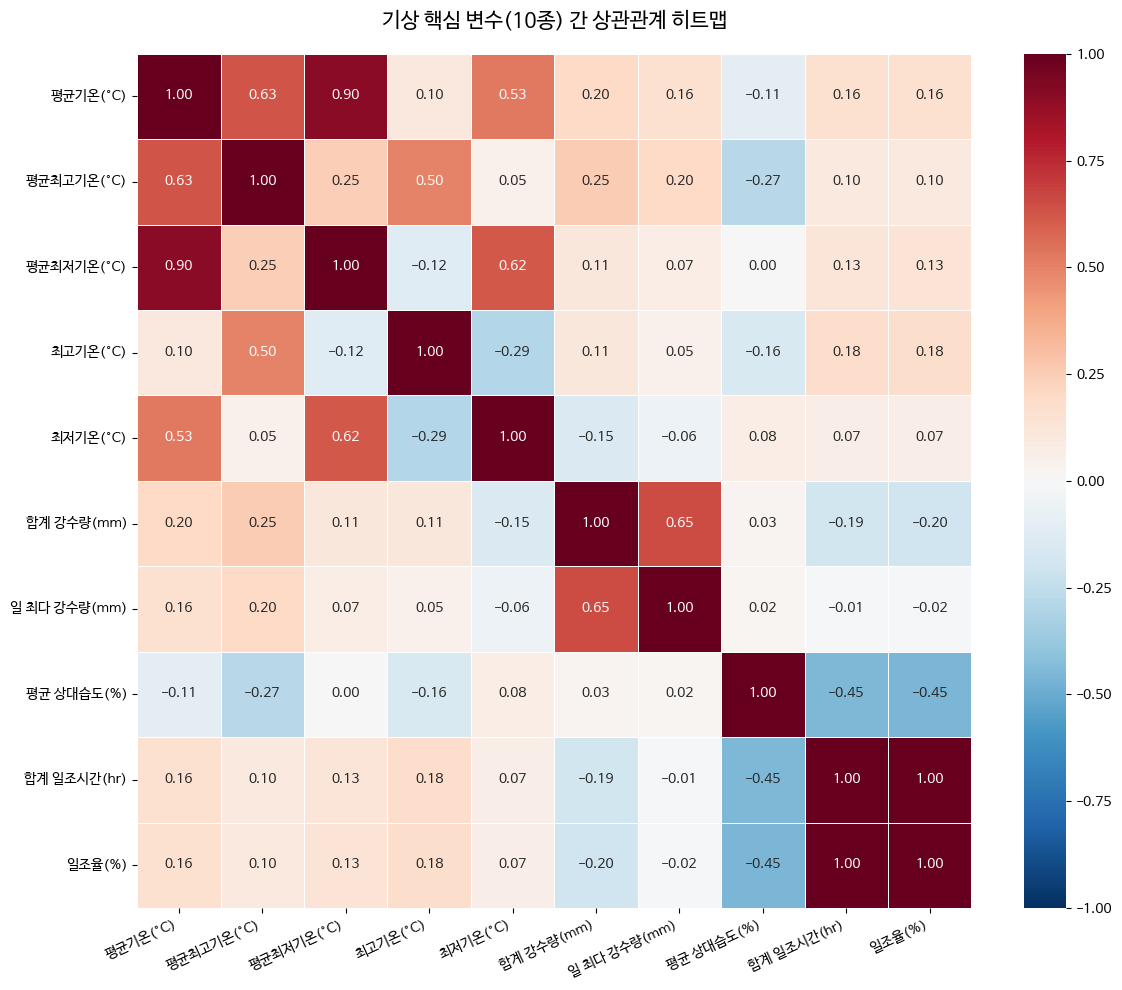

=== 5.3 기상 변수 간 상관계수 결과 테이블 ===
              평균기온(°C)  평균최고기온(°C)  평균최저기온(°C)  최고기온(°C)  최저기온(°C)  \
평균기온(°C)          1.00        0.63        0.90      0.10      0.53   
평균최고기온(°C)        0.63        1.00        0.25      0.50      0.05   
평균최저기온(°C)        0.90        0.25        1.00     -0.12      0.62   
최고기온(°C)          0.10        0.50       -0.12      1.00     -0.29   
최저기온(°C)          0.53        0.05        0.62     -0.29      1.00   
합계 강수량(mm)        0.20        0.25        0.11      0.11     -0.15   
일 최다 강수량(mm)      0.16        0.20        0.07      0.05     -0.06   
평균 상대습도(%)       -0.11       -0.27        0.00     -0.16      0.08   
합계 일조시간(hr)       0.16        0.10        0.13      0.18      0.07   
일조율(%)            0.16        0.10        0.13      0.18      0.07   

              합계 강수량(mm)  일 최다 강수량(mm)  평균 상대습도(%)  합계 일조시간(hr)  일조율(%)  
평균기온(°C)            0.20          0.16       -0.11         0.16    0.16  
평균최고기온(°C)          0.25          0.20       -0.2

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [코랩 전용 한글 폰트 설정 추가]
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 파일 불러오기 및 데이터 정제 (총 10개 핵심 변수 기준)
try:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv('기상 데이터 15~25까지.csv', encoding='utf-8')

target_cols = [
    '평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)', '최고기온(°C)', '최저기온(°C)',
    '합계 강수량(mm)', '일 최다 강수량(mm)', '평균 상대습도(%)', '합계 일조시간(hr)', '일조율(%)'
]
df_clean = df.dropna(subset=target_cols)

# 2. 10개 변수 간의 상관계수 계산
corr_matrix = df_clean[target_cols].corr()

# 3. 히트맵 시각화 (변수가 많아졌으므로 크기를 살짝 키우고 글자 회전 추가)
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,          # 칸 안에 상관계수 숫자 표시
    cmap='RdBu_r',       # 양의 상관관계는 빨간색, 음의 상관관계는 파란색
    fmt=".2f",           # 소수점 둘째 자리까지 표시
    linewidths=0.5,      # 칸 사이의 간격 테두리 선
    vmin=-1, vmax=1      # 컬러바 범위를 -1에서 1로 고정
)

plt.title('기상 핵심 변수(10종) 간 상관관계 히트맵', fontsize=15, pad=20)
plt.xticks(rotation=25, ha='right') # X축 글자가 겹치지 않게 비스듬히 회전
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. 수치 결과 출력
print("=== 5.3 기상 변수 간 상관계수 결과 테이블 ===")
print(corr_matrix.round(2))